In [ ]:
import igraph as ig
from igraph import *
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np
import networkx as nx

# Building Karate Club into Networkx network

In [ ]:
from torch_geometric.datasets import KarateClub
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_networkx

import torch
import random
import numpy as np

import pickle

# Load the data (small graph)
data = KarateClub()[0]

# Normalize features
transform = NormalizeFeatures()
data = transform(data)

G_nx = to_networkx(data, to_undirected=True)

# save G_nx
with open('/home/nisa/Thesis/experiments/phase3/data/KarateClubNet.pkl', 'wb') as f:
    pickle.dump(G_nx, f)

# Building GEPhilNet into Networkx network

Encode IDE and and names to integers

In [ ]:
df_list1 = pd.read_csv('/home/nisa/Thesis/data/fondation_members_location1.csv')
df_list2 = pd.read_csv('/home/nisa/Thesis/data/fondation_members_location2.csv')

edge_list_df = pd.concat([df_list1, df_list2], ignore_index=True)

# remove spaces from df values
edge_list_df['IDE'] = edge_list_df['IDE'].str.strip()
edge_list_df['name'] = edge_list_df['name'].str.strip()

# remove "anormal" rows where the name is missing
edge_list_df = edge_list_df[edge_list_df['origin'].isna() == False]
display(edge_list_df.shape)
print(edge_list_df['IDE'].nunique())

# initialize encoder
le1 = LabelEncoder()

# fit the same encoder to both columns "IDE" and "name"
le1.fit(pd.concat([edge_list_df['IDE'], edge_list_df['name']]))
# encode the columns
edge_list_df['IDE_Int'] = le1.transform(edge_list_df['IDE'])
edge_list_df['name_Int'] = le1.transform(edge_list_df['name'])

(6126, 4)

1327


In [ ]:
# IDE to IDE_Int mapping
IDE_mapping = edge_list_df[['IDE', 'IDE_Int']].drop_duplicates()
IDE_mapping = IDE_mapping.set_index('IDE_Int')
display(IDE_mapping.head())

# combine the locations df with the metadata df to associate the names of the foundations with the IDE
# read the metadata file
metadata1 = pd.read_csv('/home/nisa/Thesis/data/REG-foundations_metadata1.csv')
metadata2 = pd.read_csv('/home/nisa/Thesis/data/REG-foundations_metadata2.csv')
metadata = pd.concat([metadata1, metadata2], ignore_index=True)

# remove spaces from df values
metadata['Numéro IDE'] = metadata['Numéro IDE'].str.strip()

# add foundation name to the IDE mapping
IDE_mapping['Found name'] = IDE_mapping['IDE'].map(metadata.set_index('Numéro IDE')['Raison sociale'])
display(IDE_mapping.head())

# Reset index so IDE_Int becomes a column again
IDE_mapping_reset = IDE_mapping.reset_index()

# Merge the foundation name into the edge list
edge_list_df = edge_list_df.merge(IDE_mapping_reset[['IDE_Int', 'Found name']], on='IDE_Int', how='left')
ge_edge_list_df = edge_list_df.copy()

display(ge_edge_list_df.head(100))
del edge_list_df

,IDE
IDE_Int,
2160,CHE-498.839.258
1887,CHE-339.203.082
1669,CHE-204.675.847
1571,CHE-144.415.476
1268,CHE-110.411.061


,IDE,Found name
IDE_Int,,
2160,CHE-498.839.258,Fondation Evolution GEunesse
1887,CHE-339.203.082,FONDATION ARIANE LAROUX DIVORNE
1669,CHE-204.675.847,Sunday Family Philanthropic Foundation
1571,CHE-144.415.476,FONDATION PAKER
1268,CHE-110.411.061,Fondation Des Gouttes-Olivier


,IDE,name,origin,home,IDE_Int,name_Int,Found name
0,CHE-498.839.258,Mirabaud Yves,de Genève,à Collonge-Bellerive,2160,4659,Fondation Evolution GEunesse
1,CHE-498.839.258,Moro Virginie,de Genève,à Thônex,2160,4745,Fondation Evolution GEunesse
2,CHE-498.839.258,Varela-Kahlen Elisabeth,de Collonge-Bellerive,à Chêne-Bougeries,2160,6341,Fondation Evolution GEunesse
3,CHE-339.203.082,Bigler Lucienne,de Vernier,à Genève,1887,539,FONDATION ARIANE LAROUX DIVORNE
4,CHE-339.203.082,Dupanloup Pierre,de Carouge (GE),à Versoix,1887,2817,FONDATION ARIANE LAROUX DIVORNE
...,...,...,...,...,...,...,...
95,CHE-181.779.540,Meleshko Alexis,de Genève,à Anières,1635,4564,FONDATION DE L'EGLISE RUSSE DE GENEVE
96,CHE-181.779.540,Moser François,de Genève,à Genève,1635,4758,FONDATION DE L'EGLISE RUSSE DE GENEVE
97,CHE-181.779.540,Pocinoc Emilien,de France,à Genève,1635,5244,FONDATION DE L'EGLISE RUSSE DE GENEVE
98,CHE-181.779.540,Romash Alexander,des USA,à Vandoeuvres,1635,5521,FONDATION DE L'EGLISE RUSSE DE GENEVE


## Find the geneva foundations on fundraiso edgelist

In [ ]:
# transform found name of GE members edgelist to match the fundraison format xxxx-xxxx-xxx-...
import unicodedata

def format_foundation_name(name):
    if pd.isna(name):
        return name

    # Normalize accented characters (é -> e, à -> a, etc.)
    name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')

    # Apply lowercasing, strip, and replace
    name = name.strip().lower()
    name = name.replace("'", "")          # replace ' with nothing
    name = name.replace("&", "")
    name = name.replace("(", "")
    name = name.replace(")", "")
    name = name.replace(".", "")
    name = name.replace("'", "-")           # Replace apostrophes with hyphens
    name = name.replace(" - ", "-")         # Replace " - " with "-"
    name = name.replace(",", "")            # Replace "," with nothing
    name = name.replace(" ", "-")           # Replace spaces with hyphens
    name = name.replace("--", "-")

    return name

ge_edge_list_df['fundraiso found name'] = ge_edge_list_df['Found name'].apply(format_foundation_name)
display(ge_edge_list_df)

# Load financial data of all swiss foundations
swiss_fin_df = pd.read_csv('/home/nisa/Thesis/data/total_fin_data.csv')

# Get set of valid foundation names to keep only the GE ones
valid_foundations = set(ge_edge_list_df['fundraiso found name'].dropna())

# Filter rows where both 'from' and 'to' are in the valid foundation names
ge_fin_df = swiss_fin_df[
    swiss_fin_df['from'].isin(valid_foundations) &
    swiss_fin_df['to'].isin(valid_foundations)
]

print(ge_fin_df.shape)
display(ge_fin_df.head())

,IDE,name,origin,home,IDE_Int,name_Int,Found name,fundraiso found name
0,CHE-498.839.258,Mirabaud Yves,de Genève,à Collonge-Bellerive,2160,4659,Fondation Evolution GEunesse,fondation-evolution-geunesse
1,CHE-498.839.258,Moro Virginie,de Genève,à Thônex,2160,4745,Fondation Evolution GEunesse,fondation-evolution-geunesse
2,CHE-498.839.258,Varela-Kahlen Elisabeth,de Collonge-Bellerive,à Chêne-Bougeries,2160,6341,Fondation Evolution GEunesse,fondation-evolution-geunesse
3,CHE-339.203.082,Bigler Lucienne,de Vernier,à Genève,1887,539,FONDATION ARIANE LAROUX DIVORNE,fondation-ariane-laroux-divorne
4,CHE-339.203.082,Dupanloup Pierre,de Carouge (GE),à Versoix,1887,2817,FONDATION ARIANE LAROUX DIVORNE,fondation-ariane-laroux-divorne
...,...,...,...,...,...,...,...,...
6121,CHE-414.001.781,Salles Marie-Laure,de France,à Genève,2006,5642,A4A - Art for Action,a4a-art-for-action
6122,CHE-113.990.537,Anderson Brian,de Grande-Bretagne,à Contamine-sur-Arve,1420,155,Fondation Addax et Oryx,fondation-addax-et-oryx
6123,CHE-113.990.537,Campeas Talabardon Carolina,de Corsier (GE),à Chêne-Bougeries,1420,2182,Fondation Addax et Oryx,fondation-addax-et-oryx
6124,CHE-113.990.537,Codd David,de Grande-Bretagne,à Gryon,1420,2416,Fondation Addax et Oryx,fondation-addax-et-oryx


(469, 5)


,url,from,to,year,amount
1602,https://www.fundraiso.ch/en/organisations/fond...,fondation-plein-vent-emile-marthe-et-charlotte...,fondation-suisse-de-deminage-fsd,2021.0,NaN
1603,https://www.fundraiso.ch/en/organisations/fond...,fondation-plein-vent-emile-marthe-et-charlotte...,fondation-suisse-de-deminage-fsd,2020.0,NaN
1604,https://www.fundraiso.ch/en/organisations/fond...,fondation-plein-vent-emile-marthe-et-charlotte...,la-maison-de-tara,2018.0,NaN
1605,https://www.fundraiso.ch/en/organisations/fond...,fondation-plein-vent-emile-marthe-et-charlotte...,fondation-partage,2018.0,NaN
1606,https://www.fundraiso.ch/en/organisations/fond...,fondation-plein-vent-emile-marthe-et-charlotte...,fondation-partage,2017.0,NaN


In [ ]:
# Foundations in financial edges (either from or to)
used_foundations = set(ge_fin_df['from']) | set(ge_fin_df['to'])
print(f'Number of used foundations: {len(used_foundations)}')

# Foundations that exist in edge_list_df but are not used in financial edges
unused_foundations = valid_foundations - used_foundations

# Convert to DataFrame if you'd like to display or export it
unused_foundations_df = pd.DataFrame({'Unused Foundation': list(unused_foundations)})

display(unused_foundations_df.head(100))
print(f"{len(unused_foundations)} foundations not used in financial edges.")

Number of used foundations: 128


,Unused Foundation
0,fondation-horopedia
1,fondation-mv-sante
2,fondation-ninmah
3,fondation-du-centre-orthodoxe-du-patriarcat-oe...
4,fondation-alliance-armenienne
...,...
95,fondation-the-global-shapers-community
96,fondation-philanthropique-du-lions-club-geneve
97,fondation-pour-letude-du-systeme-nerveux-centr...
98,fondation-sylvestre-et-louise-antoinette-lombard


1199 foundations not used in financial edges.


## Constructing the shared board members network (node = foundation, edge = number of shared board members)
But only with the nodes present in the GE financial transaction edgelist

In [ ]:
from itertools import combinations
import networkx as nx

# Get the foundations that are in the geneva financial edgelist
valid_fin_foundations = set(ge_fin_df['from']) | set(ge_fin_df['to'])

filtered_edge_list_df = ge_edge_list_df[ge_edge_list_df['fundraiso found name'].isin(valid_fin_foundations)]

# Initialize graph
G = nx.Graph()

# Group by board member to find all foundations they belong to
grouped = filtered_edge_list_df.groupby('name')['fundraiso found name'].apply(list)

# Iterate over each board member
for foundation_list in grouped:
    # Only consider members connected to 2 or more foundations
    if len(foundation_list) < 2:
        continue

    # Create all possible foundation pairs (undirected edges)
    for f1, f2 in combinations(sorted(set(foundation_list)), 2):
        if G.has_edge(f1, f2):
            G[f1][f2]['weight'] += 1  # Increment if already exists
        else:
            G.add_edge(f1, f2, weight=1)  # Create new edge with weight = 1

# Extract weighted edge list
shared_board_df = nx.to_pandas_edgelist(G)
shared_board_df.rename(columns={'source': 'Foundation A', 'target': 'Foundation B', 'weight': 'Shared Members'}, inplace=True)

display(shared_board_df.head())

,Foundation A,Foundation B,Shared Members
0,children-action-fondation-pour-la-protection-d...,fondation-primenfance,1
1,fondation-primenfance,fondation-de-lorchestre-de-chambre-de-geneve-focg,1
2,fondation-rosemont,le-conservatoire-de-musique-de-geneve,1
3,fondation-rosemont,fondation-de-lorchestre-de-chambre-de-geneve-focg,1
4,fondation-charitable-barthelemy,fondation-charitable-bienvenue,2


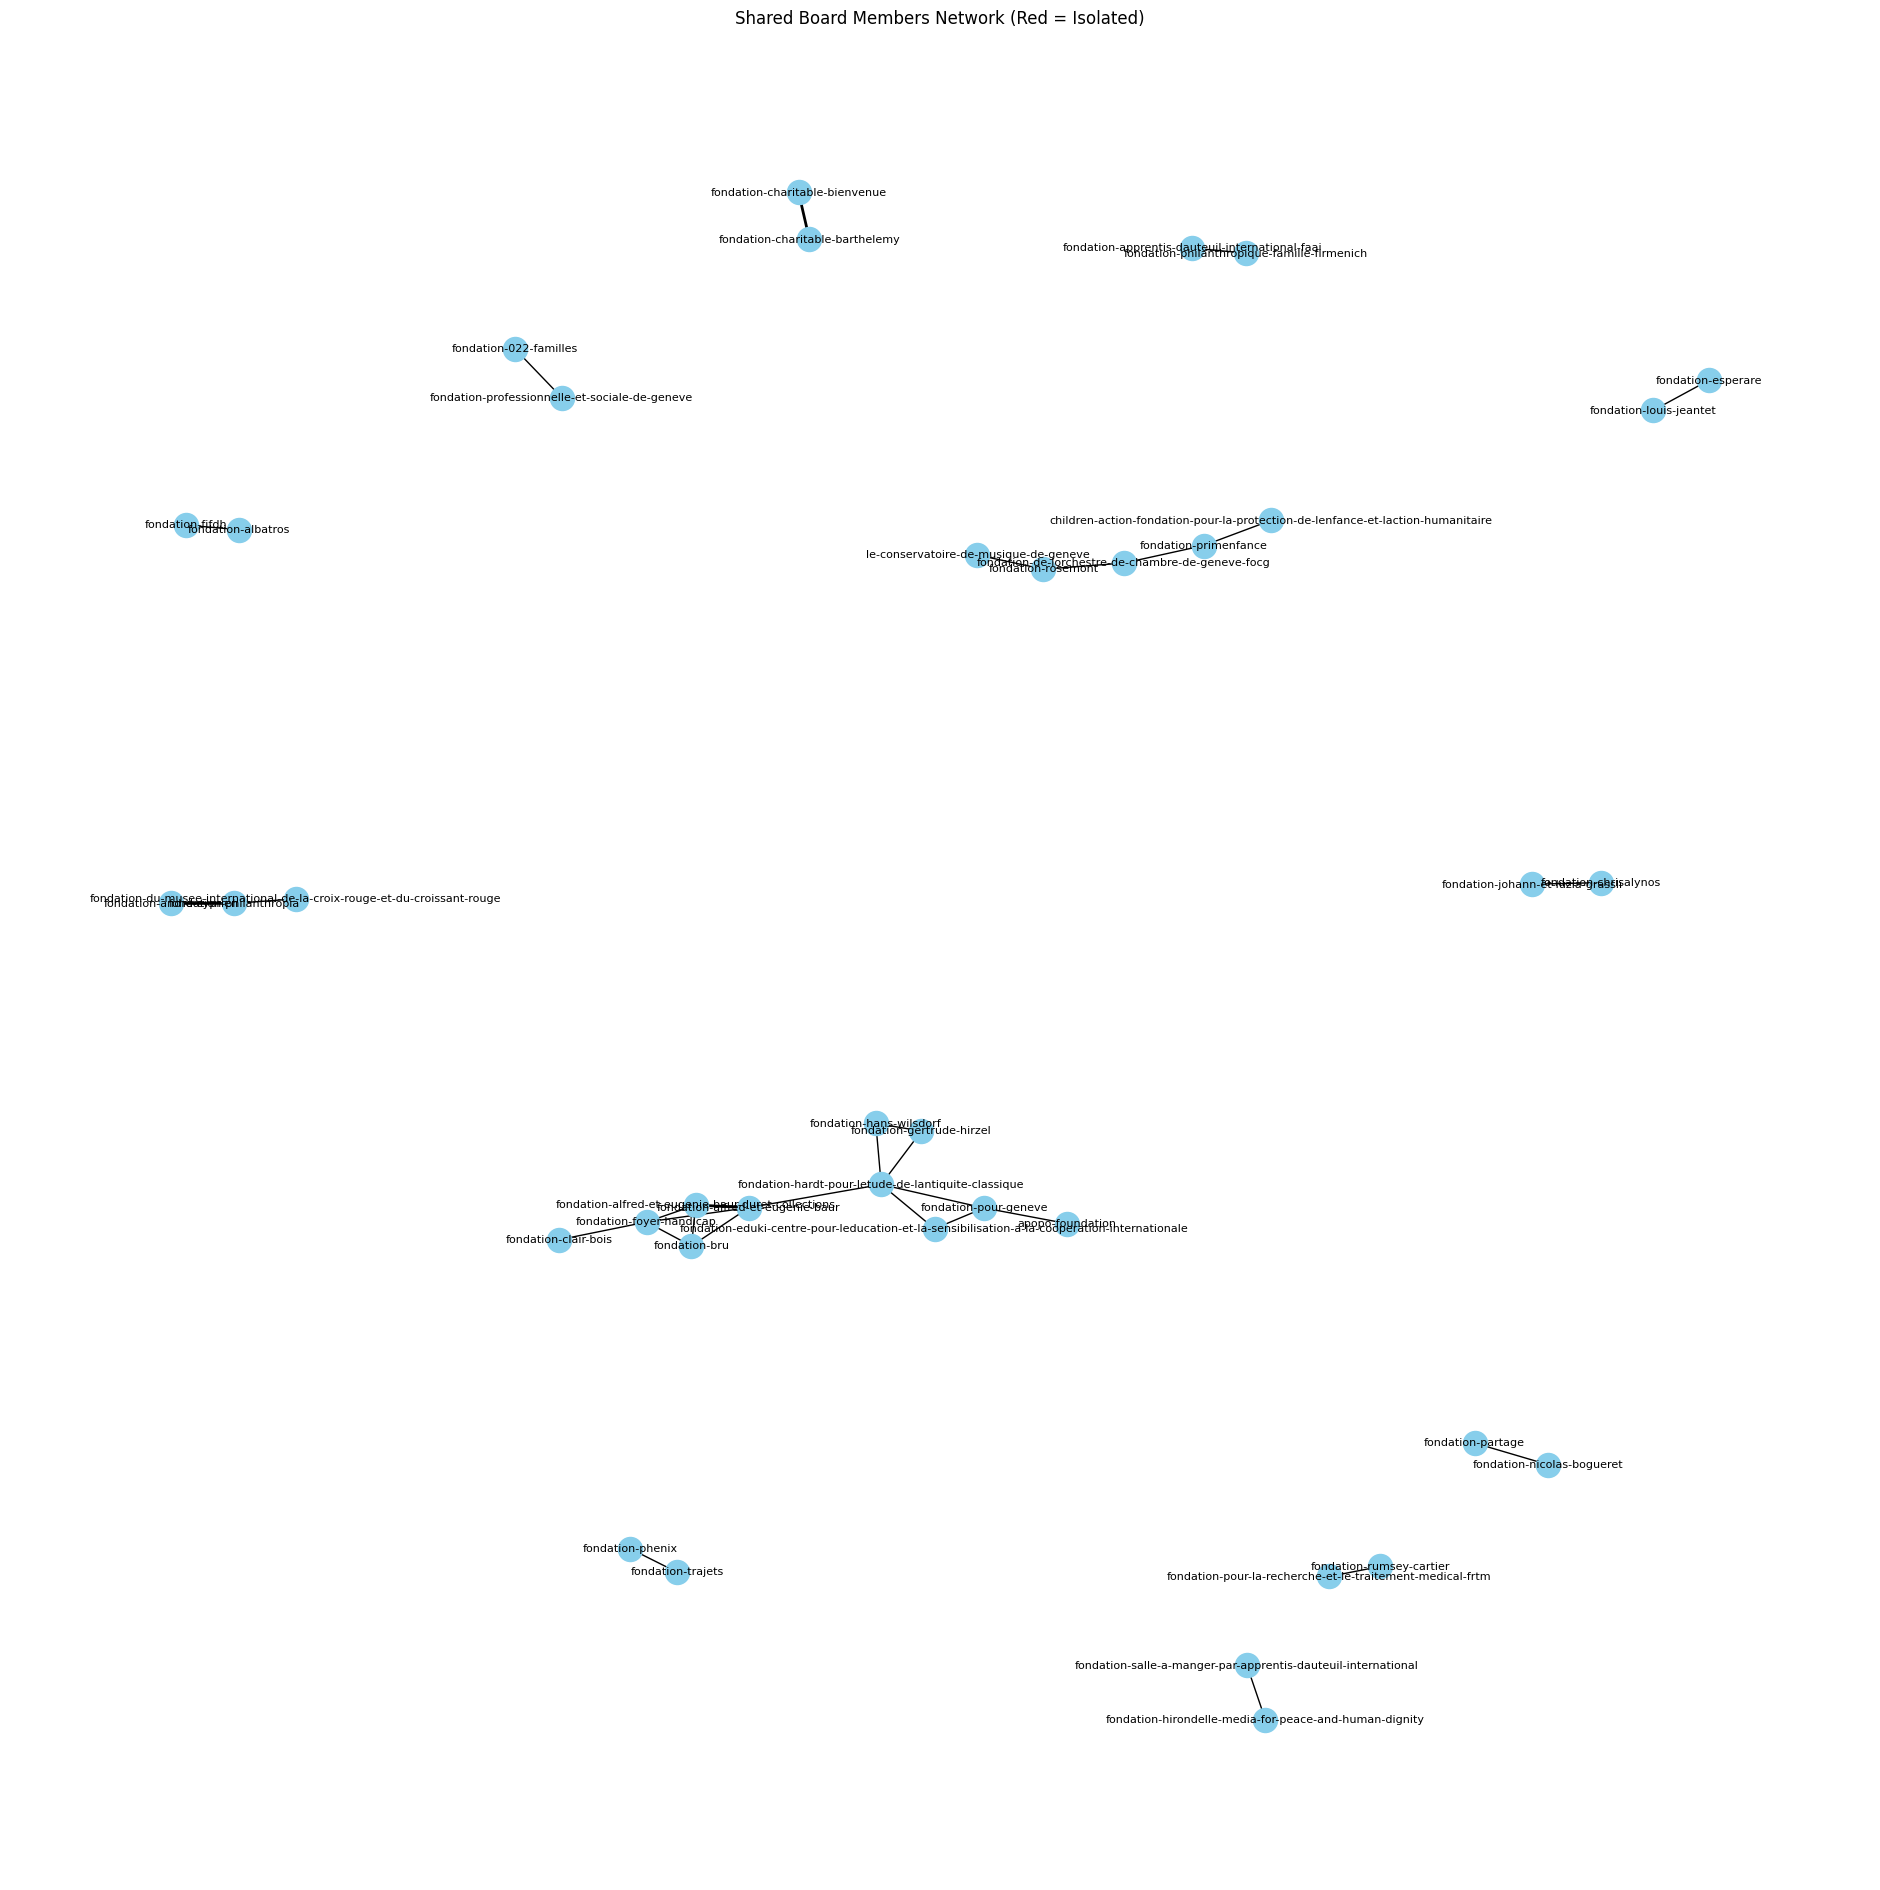

In [ ]:
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(24, 24))

# Use spring layout with all nodes passed in to ensure isolated ones are placed too
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8)

# Draw isolated nodes in red for debugging
isolated = list(nx.isolates(G))
nx.draw_networkx_nodes(G, pos, nodelist=isolated, node_color='red', node_size=300)

plt.title("Shared Board Members Network (Red = Isolated)")
plt.axis('off')
plt.show()

## Build the financial network

In [ ]:
import networkx as nx

# Group by (from, to) and count how many times each pair appears
fin_edge_freq = ge_fin_df.groupby(['from', 'to']).size().reset_index(name='frequency')

# Min-max normalization
min_freq = fin_edge_freq['frequency'].min()
max_freq = fin_edge_freq['frequency'].max()

fin_edge_freq['normalized_weight'] = (fin_edge_freq['frequency'] - min_freq) / (max_freq - min_freq)

# Create the graph only from the edge list (no pre-added nodes)
fin_G = nx.Graph()

# Add year range for each (from, to) pair
year_range = (
    ge_fin_df.groupby(['from', 'to'])['year']
    .agg(['min', 'max'])
    .reset_index()
    .rename(columns={'min': 'first_year', 'max': 'final_year'})
)
year_range['year_range'] = year_range['final_year'] - year_range['first_year']

# Merge year range info into fin_edge_freq
fin_edge_freq = fin_edge_freq.merge(year_range, on=['from', 'to'], how='left')

for _, row in fin_edge_freq.iterrows():
    fin_G.add_edge(
        row['from'],
        row['to'],
        freq=row['frequency'],
        year_range=row['year_range']+1 # if first and last year are the same, then we consider it as a single year of activity
    )

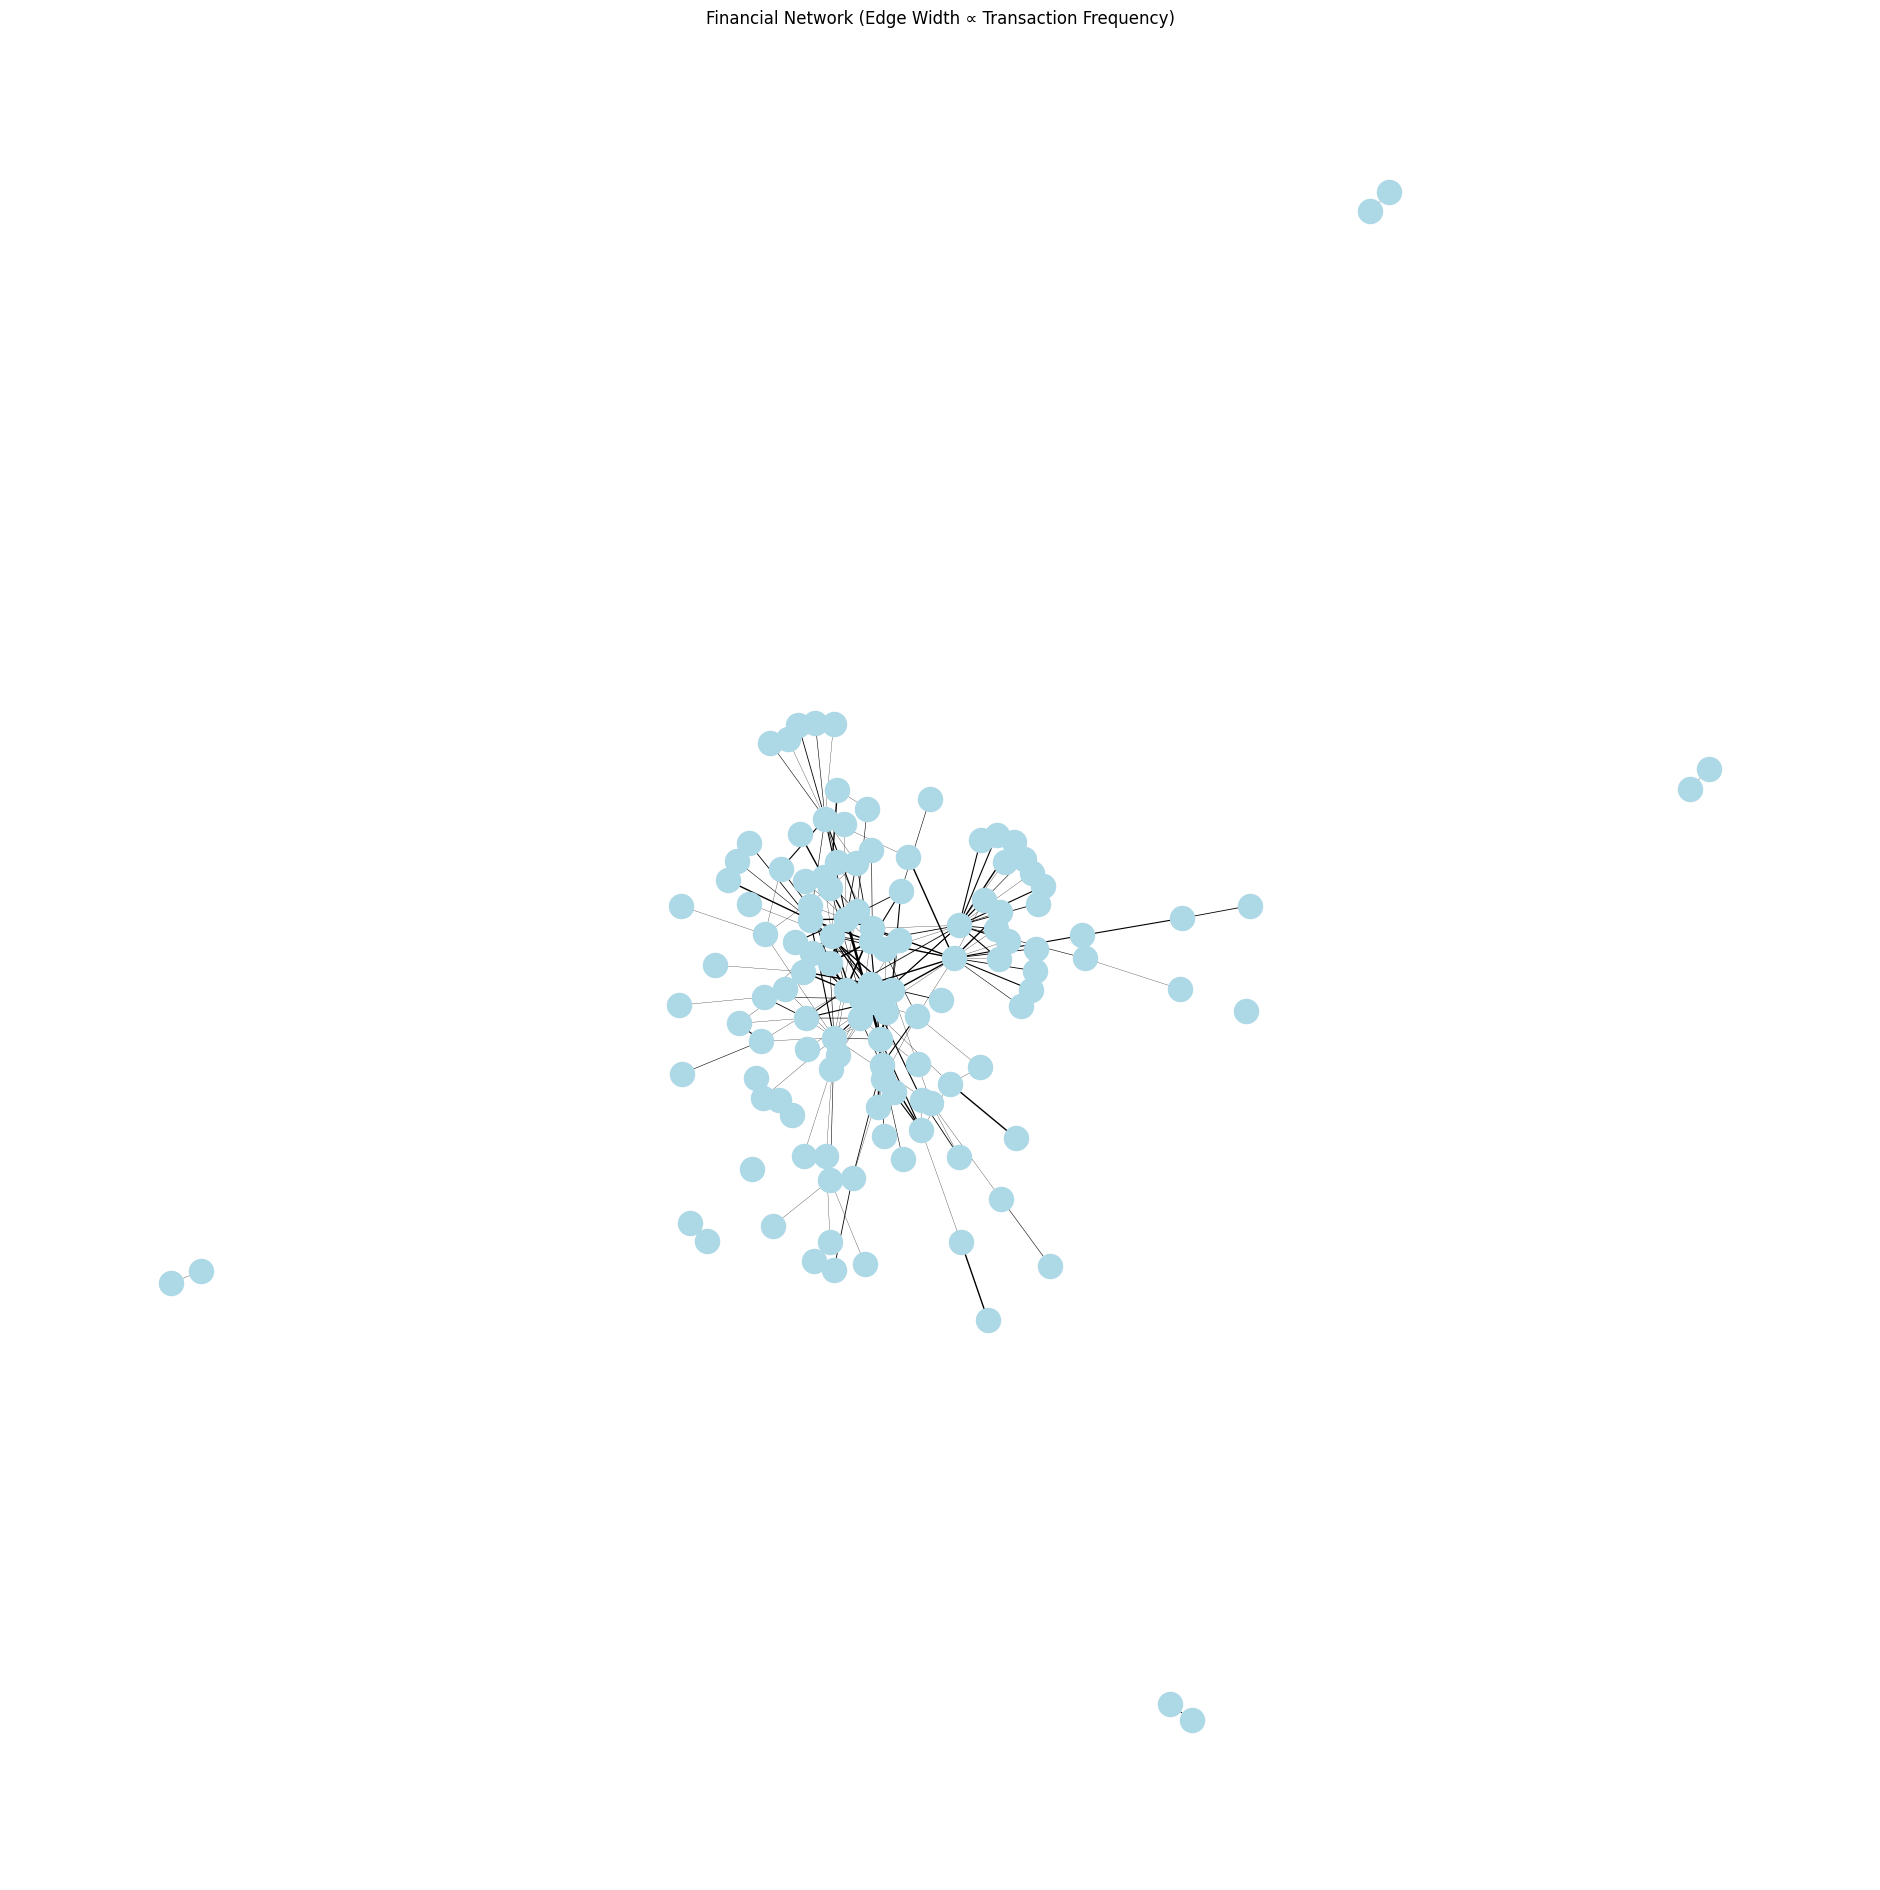

In [ ]:
plt.figure(figsize=(24, 24))
pos = nx.spring_layout(fin_G, seed=42)

nx.draw_networkx_nodes(fin_G, pos, node_size=300, node_color='lightblue')

# Scale edge thickness by normalized weight
edge_weights = [fin_G[u][v]['year_range'] * 0.2 for u, v in fin_G.edges()]
nx.draw_networkx_edges(fin_G, pos, arrows=True, width=edge_weights)

plt.title("Financial Network (Edge Width ∝ Transaction Frequency)")
plt.axis('off')
plt.show()

## Create two graphs
One with financials only and the other with both financials and shared board member

In [ ]:
import pickle

# Create a directed graph
G_combined = nx.DiGraph()

# Add only financial edges, initialize shared_board_weight to 0
for _, row in fin_edge_freq.iterrows():
    u, v = row['from'], row['to']
    G_combined.add_edge(u, v, fin_freq=row['frequency'], shared_board_weight=0)

# Update shared_board_weight for existing financial edges only
for _, row in shared_board_df.iterrows():
    u, v = row['Foundation A'], row['Foundation B']
    # Only update if the directed edge exists
    if G_combined.has_edge(u, v):
        G_combined[u][v]['shared_board_weight'] = row['Shared Members']

# Convert to pandas DataFrame
combined_edges_df = nx.to_pandas_edgelist(G_combined)
display(combined_edges_df.head())

# Save G_combined
with open('/home/nisa/Thesis/experiments/phase3/data/GePhilNet.pkl', 'wb') as f:
    pickle.dump(G_combined, f)

# check if some rows have nan values
nan_rows = combined_edges_df[combined_edges_df.isna().any(axis=1)]
if not nan_rows.empty:
    print("Rows with NaN values:")
    display(nan_rows)

,source,target,fin_freq,shared_board_weight
0,fondation-albatros,bureau-central-daide-sociale,1,0
1,fondation-albatros,fondation-apprentis-dauteuil-international-faai,1,0
2,fondation-albatros,fondation-colis-du-coeur,2,0
3,fondation-albatros,fondation-fifdh,1,1
4,fondation-albatros,fondation-otium,1,0


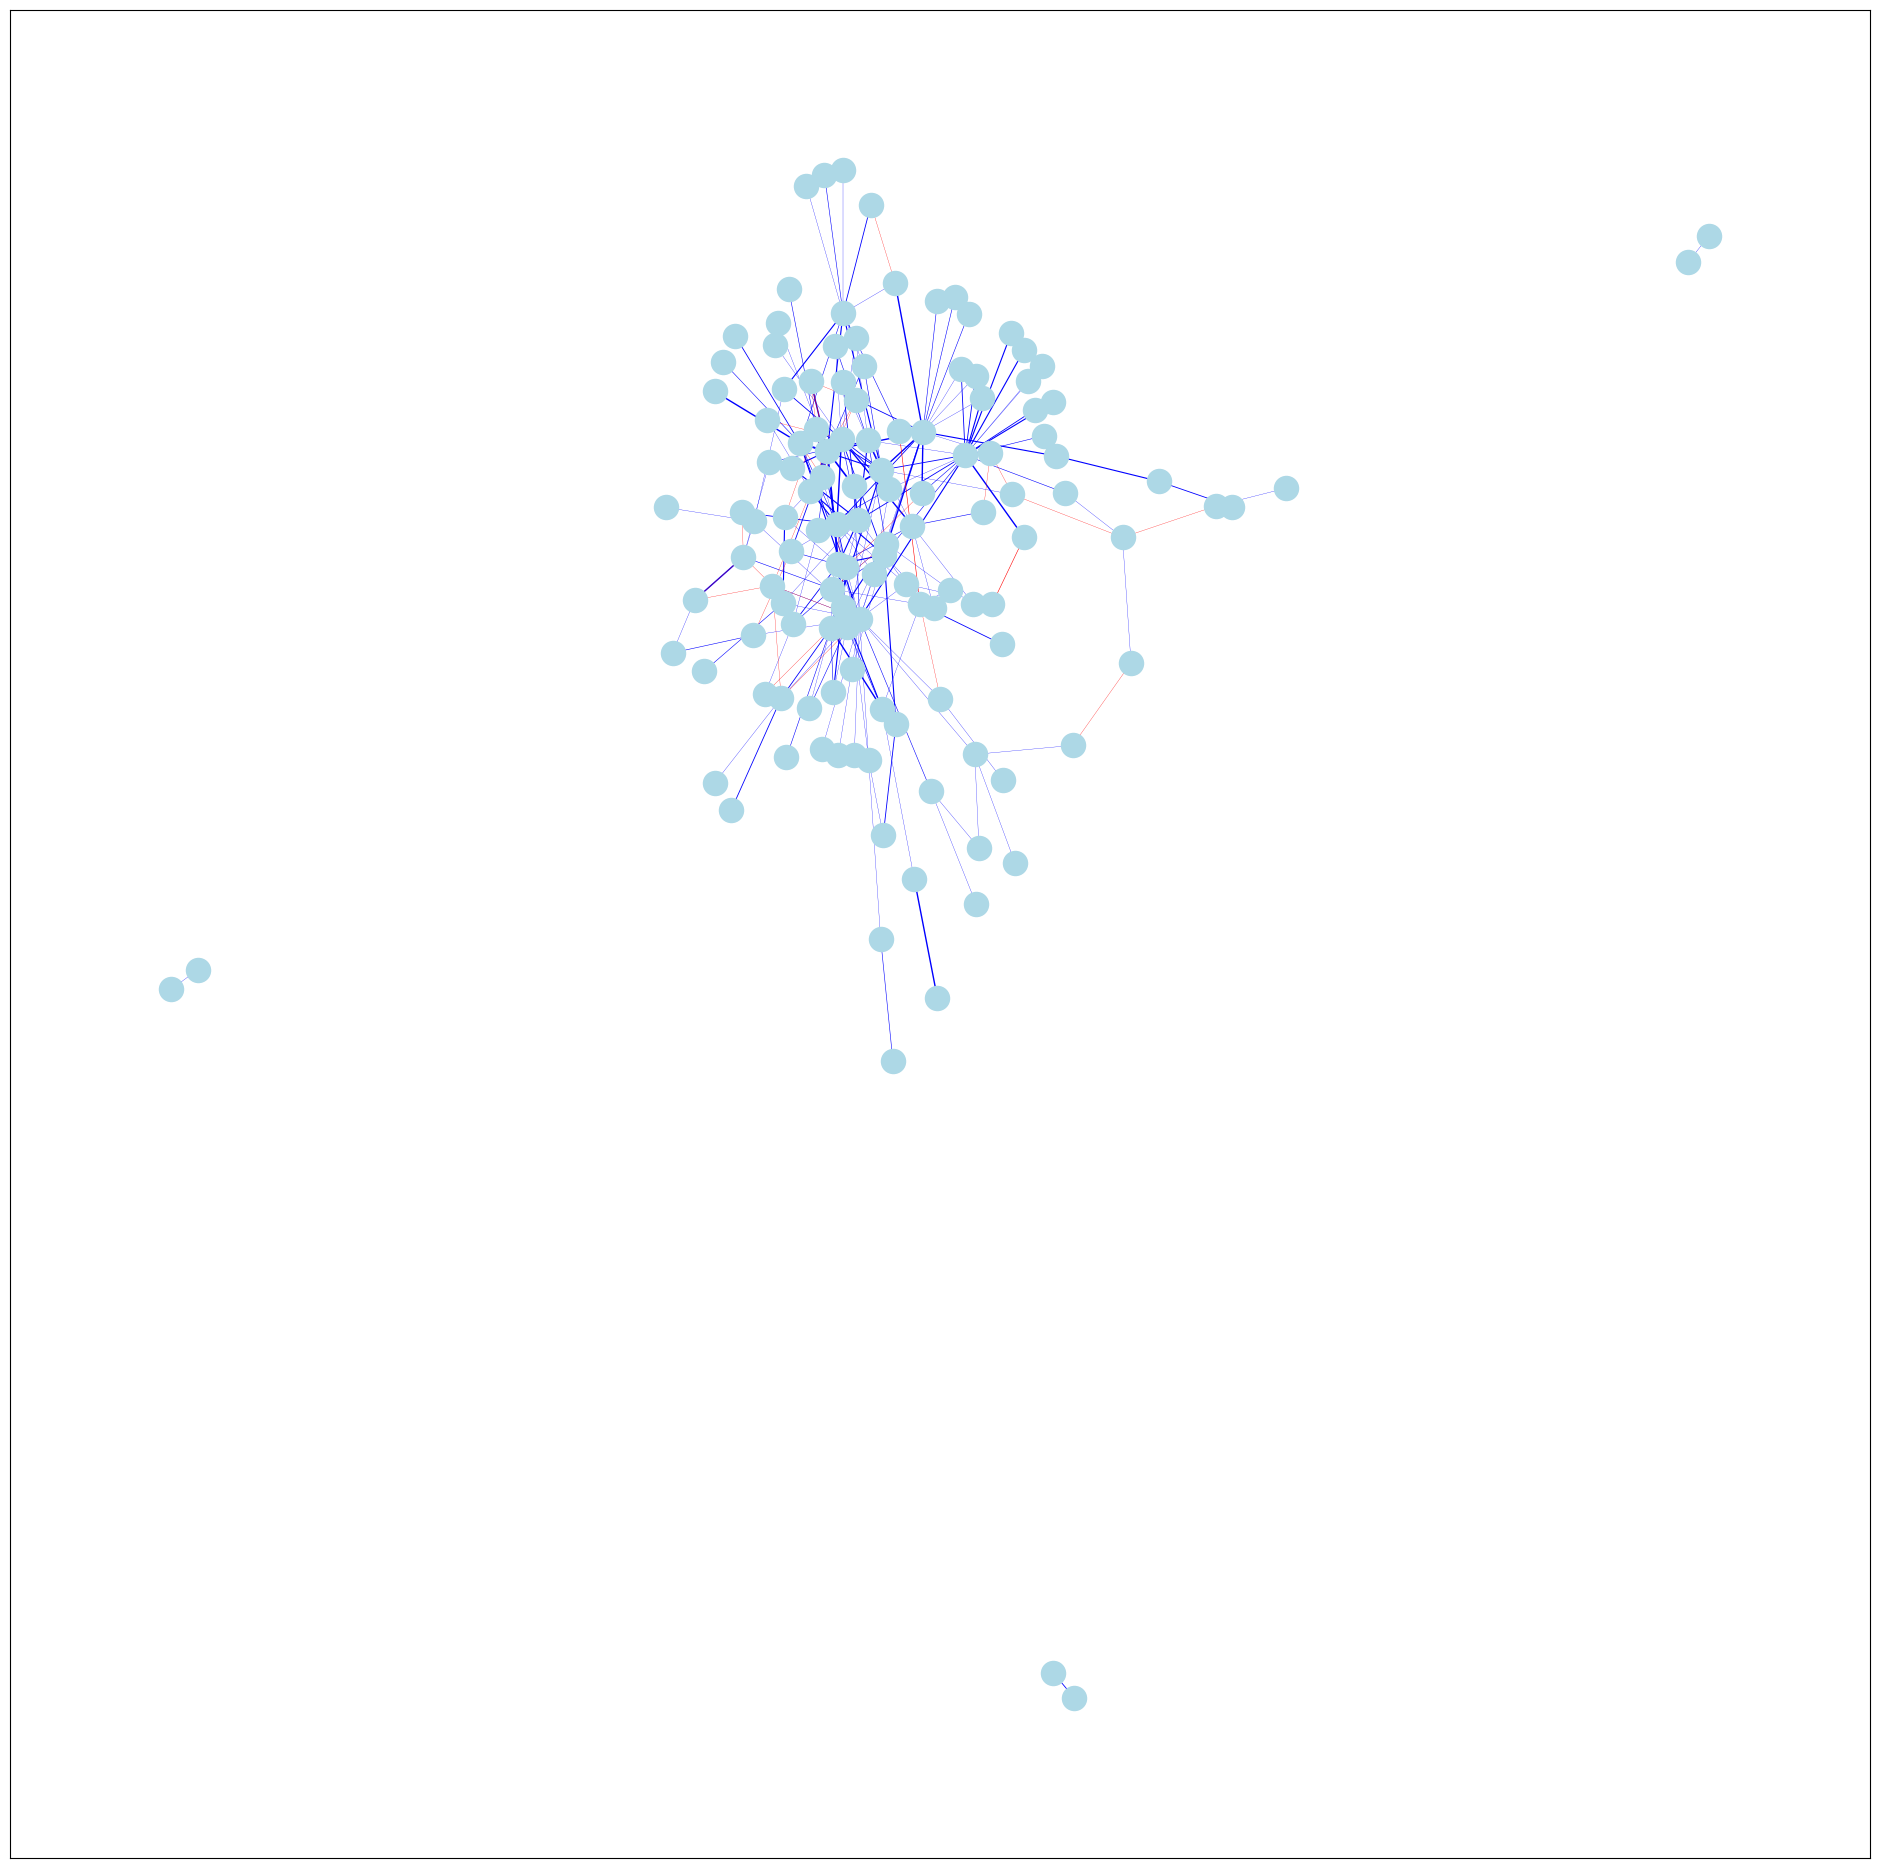

In [ ]:
# display the combined graph
plt.figure(figsize=(24, 24))
pos = nx.spring_layout(G_combined, seed=42)

# draw G_combined as first drawing the edges of fin_G in one color and then draw the edges of G (the shared board members) in another color
nx.draw_networkx_nodes(G_combined, pos, node_size=300, node_color='lightblue')
nx.draw_networkx_edges(G_combined, pos,
                       edgelist=[(u, v) for u, v, d in G_combined.edges(data=True) if d['fin_freq'] > 0],
                       width=[d['fin_freq'] * 0.2 for u, v, d in G_combined.edges(data=True) if d['fin_freq'] > 0],
                       edge_color='blue', label='Financial Transactions')
nx.draw_networkx_edges(G_combined, pos,
                       edgelist=[(u, v) for u, v, d in G_combined.edges(data=True) if d['shared_board_weight'] > 0],
                       width=[d['shared_board_weight'] * 0.2 for u, v, d in G_combined.edges(data=True) if d['shared_board_weight'] > 0],
                       edge_color='red', label='Shared Board Members')
# Draw labels
plt.show()

In [ ]:
# save G_combined
with open('/home/nisa/Thesis/experiments/phase3/data/GePhilNet.pkl', 'wb') as f:
    pickle.dump(G_combined, f)